In [1]:
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_val   = pd.read_csv('../data/processed/X_val_fe.csv')
X_test  = pd.read_csv('../data/processed/X_test_fe.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train.shape, X_val.shape, X_test.shape

((104818, 18), (22453, 18), (22459, 18))

In [2]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_train, y_train)

c:\Users\sadee\Documents\Github\loan-default-risk-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data (same leakage rule as before!)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME fitted scaler to val/test — don't re-fit
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [4]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [5]:
baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [8]:
y_pred = baseline.predict(X_val_scaled)
y_pred_proba = baseline.predict_proba(X_val_scaled)[:, 1]

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\n", classification_report(y_val, y_pred))

Accuracy: 0.805994744577562
Precision: 0.2175962293794187
Recall: 0.7486486486486487
F1: 0.3371880706025563
ROC-AUC: 0.8587400660566159

Confusion Matrix:
 [[16989  3984]
 [  372  1108]]

               precision    recall  f1-score   support

           0       0.98      0.81      0.89     20973
           1       0.22      0.75      0.34      1480

    accuracy                           0.81     22453
   macro avg       0.60      0.78      0.61     22453
weighted avg       0.93      0.81      0.85     22453



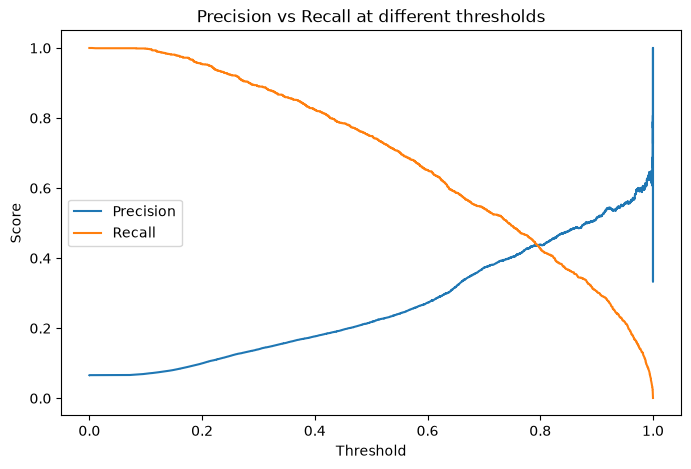

In [10]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision vs Recall at different thresholds')
plt.show()

In [11]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_pred_proba >= t).astype(int)
    p = precision_score(y_val, y_pred_t)
    r = recall_score(y_val, y_pred_t)
    print(f"Threshold {t}: Precision={p:.3f}, Recall={r:.3f}")

Threshold 0.3: Precision=0.140, Recall=0.891
Threshold 0.4: Precision=0.177, Recall=0.824
Threshold 0.5: Precision=0.218, Recall=0.749
Threshold 0.6: Precision=0.273, Recall=0.651
Threshold 0.7: Precision=0.372, Recall=0.542


In [12]:
from sklearn.metrics import average_precision_score
print("Average Precision (PR-AUC):", average_precision_score(y_val, y_pred_proba))

Average Precision (PR-AUC): 0.382585257863737


In [13]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [14]:
y_pred_rf = rf.predict(X_val)
y_pred_proba_rf = rf.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("F1:", f1_score(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_rf))
print("PR-AUC:", average_precision_score(y_val, y_pred_proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_rf))

Accuracy: 0.8097804302320403
Precision: 0.22261975750347843
Recall: 0.7567567567567568
F1: 0.3440331746275534
ROC-AUC: 0.8647199552577897
PR-AUC: 0.3806683564277649

Confusion Matrix:
 [[17062  3911]
 [  360  1120]]


In [15]:
import pandas as pd

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(10)

,feature,importance
10,TotalTimesLate,0.282154
0,RevolvingUtilizationOfUnsecuredLines,0.277405
6,NumberOfTimes90DaysLate,0.108317
2,NumberOfTime30-59DaysPastDueNotWorse,0.086444
8,NumberOfTime60-89DaysPastDueNotWorse,0.048821
1,age,0.036024
3,DebtRatio,0.030162
5,NumberOfOpenCreditLinesAndLoans,0.026863
4,MonthlyIncome,0.024992
11,IncomePerDependent,0.024028


In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42
)

gb.fit(X_train, y_train)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [17]:
y_pred_gb = gb.predict(X_val)
y_pred_proba_gb = gb.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_pred_gb))
print("Precision:", precision_score(y_val, y_pred_gb))
print("Recall:", recall_score(y_val, y_pred_gb))
print("F1:", f1_score(y_val, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba_gb))
print("PR-AUC:", average_precision_score(y_val, y_pred_proba_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_gb))

Accuracy: 0.8005611722264285
Precision: 0.21631339894019683
Recall: 0.7722972972972973
F1: 0.33796570076877586
ROC-AUC: 0.8689553074029543
PR-AUC: 0.40095614240692473

Confusion Matrix:
 [[16832  4141]
 [  337  1143]]


In [18]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    gb, X_val, y_val, 
    scoring='average_precision',
    n_repeats=5, 
    random_state=42,
    n_jobs=-1
)

importances_gb = pd.DataFrame({
    'feature': X_val.columns,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

importances_gb.head(10)

,feature,importance
10,TotalTimesLate,0.213468
0,RevolvingUtilizationOfUnsecuredLines,0.061252
6,NumberOfTimes90DaysLate,0.014209
1,age,0.012416
3,DebtRatio,0.010365
8,NumberOfTime60-89DaysPastDueNotWorse,0.008556
5,NumberOfOpenCreditLinesAndLoans,0.008108
4,MonthlyIncome,0.008106
7,NumberRealEstateLoansOrLines,0.005749
2,NumberOfTime30-59DaysPastDueNotWorse,0.002340


In [19]:
import joblib

joblib.dump(gb, '../models/gradient_boosting_model.pkl')

['../models/gradient_boosting_model.pkl']

In [20]:
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [21]:
gb_loaded = joblib.load('../models/gradient_boosting_model.pkl')
print(gb_loaded.predict_proba(X_val)[:5])  # should match your original predictions

[[0.74405125 0.25594875]
 [0.14126154 0.85873846]
 [0.15811073 0.84188927]
 [0.86576886 0.13423114]
 [0.87954081 0.12045919]]


In [22]:
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_val   = pd.read_csv('../data/processed/X_val_fe.csv')
X_test  = pd.read_csv('../data/processed/X_test_fe.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train.shape

(104818, 15)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred = baseline.predict(X_val_scaled)
y_pred_proba = baseline.predict_proba(X_val_scaled)[:, 1]

print("LogReg — Accuracy:", accuracy_score(y_val, y_pred))
print("LogReg — Precision:", precision_score(y_val, y_pred))
print("LogReg — Recall:", recall_score(y_val, y_pred))
print("LogReg — ROC-AUC:", roc_auc_score(y_val, y_pred_proba))

LogReg — Accuracy: 0.8058165946644101
LogReg — Precision: 0.217425431711146
LogReg — Recall: 0.7486486486486487
LogReg — ROC-AUC: 0.8587475402737884


In [24]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_pred_proba_rf = rf.predict_proba(X_val)[:, 1]

print("RF — Accuracy:", accuracy_score(y_val, y_pred_rf))
print("RF — Precision:", precision_score(y_val, y_pred_rf))
print("RF — Recall:", recall_score(y_val, y_pred_rf))
print("RF — ROC-AUC:", roc_auc_score(y_val, y_pred_proba_rf))
print("RF — PR-AUC:", average_precision_score(y_val, y_pred_proba_rf))

RF — Accuracy: 0.8157484523226295
RF — Precision: 0.2278221675886089
RF — Recall: 0.7513513513513513
RF — ROC-AUC: 0.8651023001259018
RF — PR-AUC: 0.3822968666964382


In [25]:
gb = HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)
y_pred_proba_gb = gb.predict_proba(X_val)[:, 1]

print("GB — Accuracy:", accuracy_score(y_val, y_pred_gb))
print("GB — Precision:", precision_score(y_val, y_pred_gb))
print("GB — Recall:", recall_score(y_val, y_pred_gb))
print("GB — ROC-AUC:", roc_auc_score(y_val, y_pred_proba_gb))
print("GB — PR-AUC:", average_precision_score(y_val, y_pred_proba_gb))

GB — Accuracy: 0.8005611722264285
GB — Precision: 0.21631339894019683
GB — Recall: 0.7722972972972973
GB — ROC-AUC: 0.8689553074029543
GB — PR-AUC: 0.40095614240692473


In [26]:
import joblib

joblib.dump(gb, '../models/gradient_boosting_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']